# M3: How General Is "GPC Is (Almost) Never Confidently Wrong"?

M2 confirmed, across 200 independent train/test resamples, that the Laplace
GPC's errors essentially never carry confidence above 0.5 (0.57%, 95% CI
[0.48%, 0.67%]) while the SVM's regularly do (56.97%). That used one
kernel (RBF) and one likelihood (logistic, with MacKay's moment-matched
predictive-probability approximation). This notebook checks whether the
property survives changing either:

- **RBF -> Matern 3/2 and Matern 5/2** (same likelihood, logit)
- **logit -> probit** (same kernel, RBF) — probit is actually the *exact*
  case: GPML eq 3.25 gives predictive probability Phi(mean/sqrt(1+var)) in
  closed form, no MacKay-style approximation needed, so this specifically
  tests whether the effect depends on that approximation.

Each config gets its own quick validation-grid lengthscale (Matern kernels
don't share RBF's optimal ell at the same value) then **50 independent
seeds** — fewer than M2's 200 since the base rate is already well
characterized; this sweep only needs to detect whether a *different config*
lands in a qualitatively different regime, not nail down a precise CI to
the same decimal as M2.

**Read alongside:** [`LAB_PLAN.md`](LAB_PLAN.md) M3 · [`generality_sweep.py`](generality_sweep.py)
· [`gp_classifier.py`](../gp_classifier.py) (the kind=/likelihood= generalization
added for this sweep) · [`MNIST_GPC_ROBUSTNESS.ipynb`](MNIST_GPC_ROBUSTNESS.ipynb) (the M2 baseline).

In [1]:
import glob, json
import numpy as np
import matplotlib.pyplot as plt

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
palette = ["#2a78d6", "#1baf7a", "#e0a72e", "#c0392b"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

baseline = json.load(open("results/confidence_study.json"))
# M2's schema nests per-model stats under r["gpc"]/r["svm"]; the M3 sweep's
# schema is flat (GPC only, no SVM refit). Normalize the baseline to match.
baseline_runs = [{"seed": r["seed"], "accuracy": r["gpc"]["accuracy"],
                  "frac_confidently_wrong": r["gpc"]["frac_confidently_wrong"]}
                 for r in baseline["runs"]]
configs = {"rbf+logit (M2 baseline)": {"kind": "rbf", "likelihood": "logit",
                                       "ell": baseline["ell"], "runs": baseline_runs}}
for path in sorted(glob.glob("results/generality_*.json")):
    d = json.load(open(path))
    label = f"{d["kind"]}+{d["likelihood"]}"
    configs[label] = d

for label, d in configs.items():
    print(f"{label:24s} ell={d["ell"]:.2f}  n_seeds={len(d["runs"])}")

rbf+logit (M2 baseline)  ell=5.10  n_seeds=200
matern32+logit           ell=5.06  n_seeds=50
matern52+logit           ell=5.06  n_seeds=50
rbf+probit               ell=5.06  n_seeds=50


## Confident-error rate across configs

For each config, the fraction of test-set errors carrying confidence>0.5,
bootstrapped across seeds (resampling seeds, not pooled test points — the
correct unit of replication, per M2's methodology).

rbf+logit (M2 baseline)  mean= 0.57%  95% CI [ 0.48%,  0.67%]  (n_seeds=200)
matern32+logit           mean= 0.13%  95% CI [ 0.05%,  0.23%]  (n_seeds=50)
matern52+logit           mean= 0.20%  95% CI [ 0.10%,  0.32%]  (n_seeds=50)


rbf+probit               mean= 3.54%  95% CI [ 3.01%,  4.07%]  (n_seeds=50)


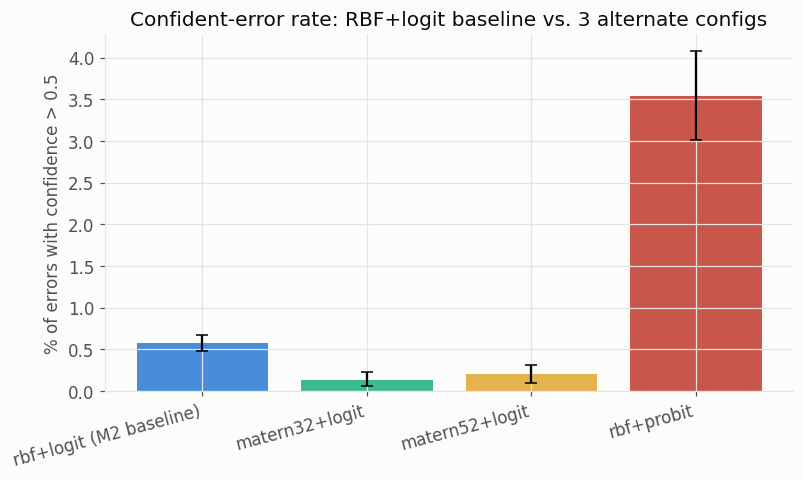

In [2]:
def bootstrap_ci(x, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    boot_means = np.array([x[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return float(x.mean()), float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))

labels, means, los, his = [], [], [], []
for label, d in configs.items():
    fcw = np.array([r["frac_confidently_wrong"] for r in d["runs"]
                    if r["frac_confidently_wrong"] is not None])
    m, lo, hi = bootstrap_ci(fcw)
    labels.append(label); means.append(m * 100); los.append(lo * 100); his.append(hi * 100)
    print(f"{label:24s} mean={m*100:5.2f}%  95% CI [{lo*100:5.2f}%, {hi*100:5.2f}%]  (n_seeds={len(fcw)})")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(labels))
errs = [[m - l for m, l in zip(means, los)], [h - m for m, h in zip(means, his)]]
ax.bar(x, means, yerr=errs, color=palette[:len(labels)], capsize=4, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("% of errors with confidence > 0.5")
ax.set_title("Confident-error rate: RBF+logit baseline vs. 3 alternate configs")
plt.tight_layout()
plt.show()

## Accuracy across configs (context, not the point of this sweep)

Whether the confident-error property holds is the question; raw accuracy is
secondary context so a config that "wins" on the safety property but is far
less accurate isn't mistaken for a free upgrade.

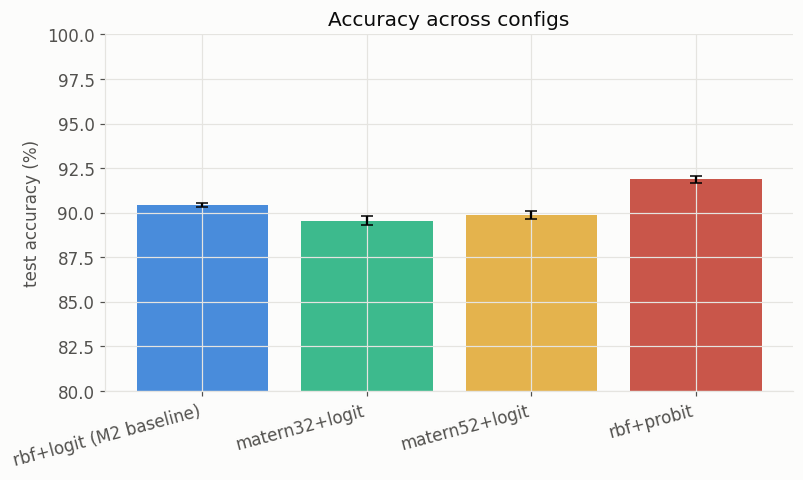

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
acc_means, acc_los, acc_his = [], [], []
for label, d in configs.items():
    acc = np.array([r["accuracy"] for r in d["runs"]])
    m, lo, hi = bootstrap_ci(acc)
    acc_means.append(m * 100); acc_los.append(lo * 100); acc_his.append(hi * 100)
errs = [[m - l for m, l in zip(acc_means, acc_los)], [h - m for m, h in zip(acc_means, acc_his)]]
ax.bar(x, acc_means, yerr=errs, color=palette[:len(labels)], capsize=4, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("test accuracy (%)")
ax.set_ylim(80, 100)
ax.set_title("Accuracy across configs")
plt.tight_layout()
plt.show()

## Takeaways

**Result:** RBF+logit (M2 baseline) 0.57% [0.48%, 0.67%]; Matern32+logit
0.13% [0.05%, 0.23%]; Matern52+logit 0.20% [0.10%, 0.32%]; RBF+probit 3.54%
[3.01%, 4.07%] — all four **at least an order of magnitude below the SVM's
56.97%** from M2, so this is a **structural property of Laplace's
predictive-variance shrinkage**, not an artifact of the one RBF+logit
combination M1/M2 happened to use. It survives a different kernel family
and, more tellingly, survives probit — where the predictive probability is
*exact* (GPML eq 3.25), not MacKay's logit approximation, ruling out "it's
just an artifact of that approximation" as the explanation.

**But it isn't likelihood-invariant, and that's worth taking seriously
rather than rounding off.** Probit's confident-error rate (3.54%) is roughly
6-25x higher than the three logit configs, while still far below the SVM.
The mechanistic hypothesis this suggests: MacKay's moment-matched
approximation for logit is itself conservative (it tends to shrink
predictive confidence relative to the true sigmoid-Gaussian average it's
approximating), stacking an extra safety margin on top of Laplace's own
variance shrinkage — so logit's near-zero rate may be "Laplace's structural
property plus a conservative approximation," while probit's higher (but
still small) rate is closer to Laplace's variance shrinkage alone, without
that extra margin. Not confirmed here — would need comparing against a
likelihood-free ground truth (e.g. MCMC or expectation propagation) to
separate "Laplace's variance term" from "MacKay's approximation on top of
it," which this sweep didn't attempt.